# Notebook 3 - IC Software Comparison

Compare Connectivity Index (IC) outputs from:

1. `GeomorphConn` (this package)
2. ArcGIS Pro ModelBuilder output
3. Cavalli's SedInConnect (Crema & Cavalli, 2018)

This notebook computes pixel-wise agreement metrics, inferential statistical tests, and map/graph diagnostics.


## Inputs

Provide 3 co-registered IC rasters in the same CRS, extent, and resolution.

If rasters are not aligned, this notebook reprojects ArcGIS and SedInConnect rasters to the `GeomorphConn` grid using bilinear resampling.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_context('notebook')
sns.set_style('whitegrid')

# ---- USER INPUTS ----
IC_GEOMORPHCONN = Path('data/CLI_GeomorphConnIC.tif')
IC_ARCGIS = Path('data/ic_arcgis_modelbuilder.tif')
IC_SEDINCONNECT = Path('data/ic_sedinconnectArcGISTauCavalli.tif')

OUT_DIR = Path('outputs/ic_comparison')
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [IC_GEOMORPHCONN, IC_ARCGIS, IC_SEDINCONNECT]:
    if not p.exists():
        raise FileNotFoundError(f'Missing input raster: {p}')

print('Input rasters found. Output dir:', OUT_DIR)

Input rasters found. Output dir: outputs/ic_comparison


In [4]:
def open_singleband(path: Path) -> xr.DataArray:
    da = xr.open_dataarray(path, masked=True).squeeze(drop=True)
    da.name = path.stem
    return da

ic_geomorphconn = open_singleband(IC_GEOMORPHCONN)
ic_arcgis = open_singleband(IC_ARCGIS)
ic_sedin = open_singleband(IC_SEDINCONNECT)

# Reproject to GeomorphConn grid for exact pixel-to-pixel comparisons
ic_arcgis = ic_arcgis.rio.reproject_match(ic_geomorphconn)
ic_sedin = ic_sedin.rio.reproject_match(ic_geomorphconn)

stack = xr.Dataset({
    'GeomorphConn': ic_geomorphconn,
    'arcgis': ic_arcgis,
    'sedinconnect': ic_sedin,
})

# Valid mask: finite in all three maps
valid = np.isfinite(stack['GeomorphConn']) & np.isfinite(stack['arcgis']) & np.isfinite(stack['sedinconnect'])
stack_valid = stack.where(valid)

n_valid = int(valid.sum().item())
print(f'Valid co-located pixels: {n_valid:,}')

/home/manu/miniconda3/envs/dev_geomorphmapper/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Valid co-located pixels: 4,591,149


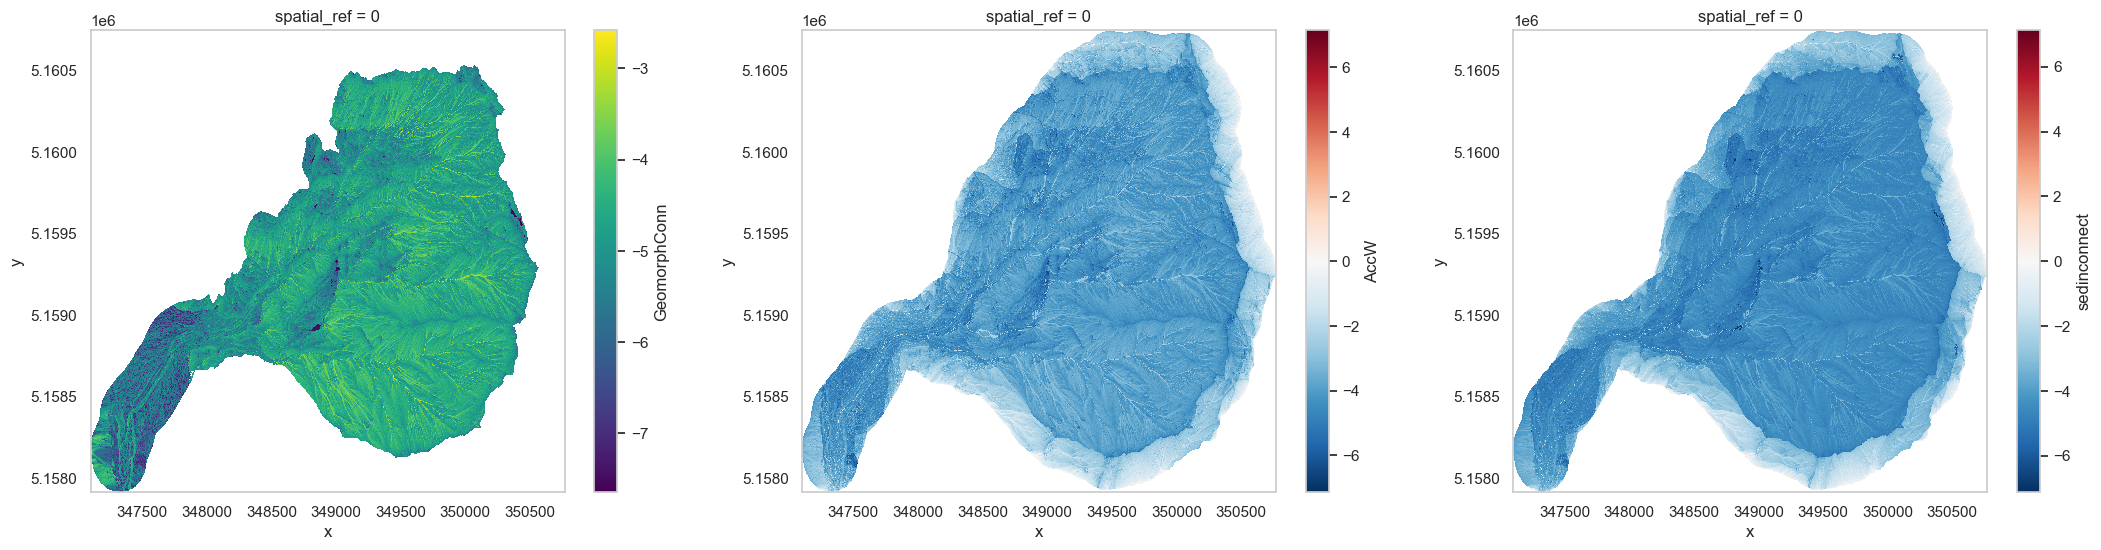

In [11]:
fig, ax = plt.subplots(1,3, figsize=(26,6))

stack.GeomorphConn.plot(ax=ax[0])
stack.arcgis.plot(ax=ax[1])
stack.sedinconnect.plot(ax=ax[2])

In [8]:
stack

<xarray.Dataset> Size: 125MB
Dimensions:       (x: 3667, y: 2835)
Coordinates:
  * x             (x) float64 29kB 3.471e+05 3.471e+05 ... 3.508e+05 3.508e+05
  * y             (y) float64 23kB 5.161e+06 5.161e+06 ... 5.158e+06 5.158e+06
    spatial_ref   int64 8B 0
Data variables:
    GeomorphConn  (y, x) float32 42MB nan nan nan nan nan ... nan nan nan nan
    arcgis        (y, x) float32 42MB nan nan nan nan nan ... nan nan nan nan
    sedinconnect  (y, x) float32 42MB nan nan nan nan nan ... nan nan nan nan

In [5]:
def flatten_valid(a: xr.DataArray) -> np.ndarray:
    vals = a.values.ravel()
    vals = vals[np.isfinite(vals)]
    return vals

s = flatten_valid(stack_valid['GeomorphConn'])
a = flatten_valid(stack_valid['arcgis'])
c = flatten_valid(stack_valid['sedinconnect'])

def basic_metrics(x: np.ndarray, y: np.ndarray) -> dict:
    diff = x - y
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    nrmse = float(rmse / (np.nanmax(y) - np.nanmin(y) + 1e-12))
    r_pearson = float(stats.pearsonr(x, y).statistic)
    r_spearman = float(stats.spearmanr(x, y).statistic)
    r_kendall = float(stats.kendalltau(x, y).statistic)
    r2 = float(np.corrcoef(x, y)[0, 1] ** 2)
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Bias(x-y)': bias,
        'NRMSE': nrmse,
        'Pearson_r': r_pearson,
        'Spearman_rho': r_spearman,
        'Kendall_tau': r_kendall,
        'R2': r2,
    }

comparisons = {
    'geomorphconn_vs_arcgis': basic_metrics(s, a),
    'geomorphconn_vs_sedinconnect': basic_metrics(s, c),
    'arcgis_vs_sedinconnect': basic_metrics(a, c),
}

metrics_df = pd.DataFrame(comparisons).T
metrics_df.round(5)

,RMSE,MAE,Bias(x-y),NRMSE,Pearson_r,Spearman_rho,Kendall_tau,R2
geomorphconn_vs_arcgis,0.94254,0.78415,-0.78375,0.09187,0.59943,0.75479,0.68039,0.35931
geomorphconn_vs_sedinconnect,0.69094,0.33038,-0.32905,0.06749,0.38936,0.64818,0.60445,0.15160
arcgis_vs_sedinconnect,0.52030,0.48684,0.45470,0.05082,0.90006,0.93195,0.81759,0.81010


In [12]:
def inferential_tests(x: np.ndarray, y: np.ndarray) -> dict:
    # Subsample for expensive tests if very large
    n = len(x)
    max_n = 200000
    if n > max_n:
        idx = np.random.default_rng(42).choice(n, max_n, replace=False)
        x_use = x[idx]
        y_use = y[idx]
    else:
        x_use = x
        y_use = y

    out = {}
    out['n_test'] = len(x_use)

    # Paired t-test (mean difference)
    t_res = stats.ttest_rel(x_use, y_use, nan_policy='omit')
    out['paired_t_stat'] = float(t_res.statistic)
    out['paired_t_pvalue'] = float(t_res.pvalue)

    # Wilcoxon signed-rank (median difference)
    try:
        w_res = stats.wilcoxon(x_use, y_use, zero_method='wilcox')
        out['wilcoxon_stat'] = float(w_res.statistic)
        out['wilcoxon_pvalue'] = float(w_res.pvalue)
    except ValueError:
        out['wilcoxon_stat'] = np.nan
        out['wilcoxon_pvalue'] = np.nan

    # Two-sample KS test (distribution equality)
    ks_res = stats.ks_2samp(x_use, y_use)
    out['ks_stat'] = float(ks_res.statistic)
    out['ks_pvalue'] = float(ks_res.pvalue)

    return out

tests_df = pd.DataFrame({
    'geomorphconn_vs_arcgis': inferential_tests(s, a),
    'geomorphconn_vs_sedinconnect': inferential_tests(s, c),
    'arcgis_vs_sedinconnect': inferential_tests(a, c),
}).T

tests_df.round(6)

,n_test,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue,ks_stat,ks_pvalue
geomorphconn_vs_arcgis,200000.0,-667.369299,0.0,2337374.5,0.0,0.55906,0.0
geomorphconn_vs_sedinconnect,200000.0,-241.547728,0.0,148024447.0,0.0,0.24958,0.0
arcgis_vs_sedinconnect,200000.0,809.648158,0.0,412748004.5,0.0,0.44826,0.0


In [13]:
# Save tables
metrics_path = OUT_DIR / 'comparison_metrics.csv'
tests_path = OUT_DIR / 'comparison_tests.csv'
metrics_df.to_csv(metrics_path)
tests_df.to_csv(tests_path)

print('Saved:', metrics_path)
print('Saved:', tests_path)

display(metrics_df.round(5))
display(tests_df.round(6))

Saved: outputs/ic_comparison/comparison_metrics.csv
Saved: outputs/ic_comparison/comparison_tests.csv


,RMSE,MAE,Bias(x-y),NRMSE,Pearson_r,Spearman_rho,Kendall_tau,R2
geomorphconn_vs_arcgis,0.94254,0.78415,-0.78375,0.09187,0.59943,0.75479,0.68039,0.35931
geomorphconn_vs_sedinconnect,0.69094,0.33038,-0.32905,0.06749,0.38936,0.64818,0.60445,0.15160
arcgis_vs_sedinconnect,0.52030,0.48684,0.45470,0.05082,0.90006,0.93195,0.81759,0.81010


,n_test,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue,ks_stat,ks_pvalue
geomorphconn_vs_arcgis,200000.0,-667.369299,0.0,2337374.5,0.0,0.55906,0.0
geomorphconn_vs_sedinconnect,200000.0,-241.547728,0.0,148024447.0,0.0,0.24958,0.0
arcgis_vs_sedinconnect,200000.0,809.648158,0.0,412748004.5,0.0,0.44826,0.0


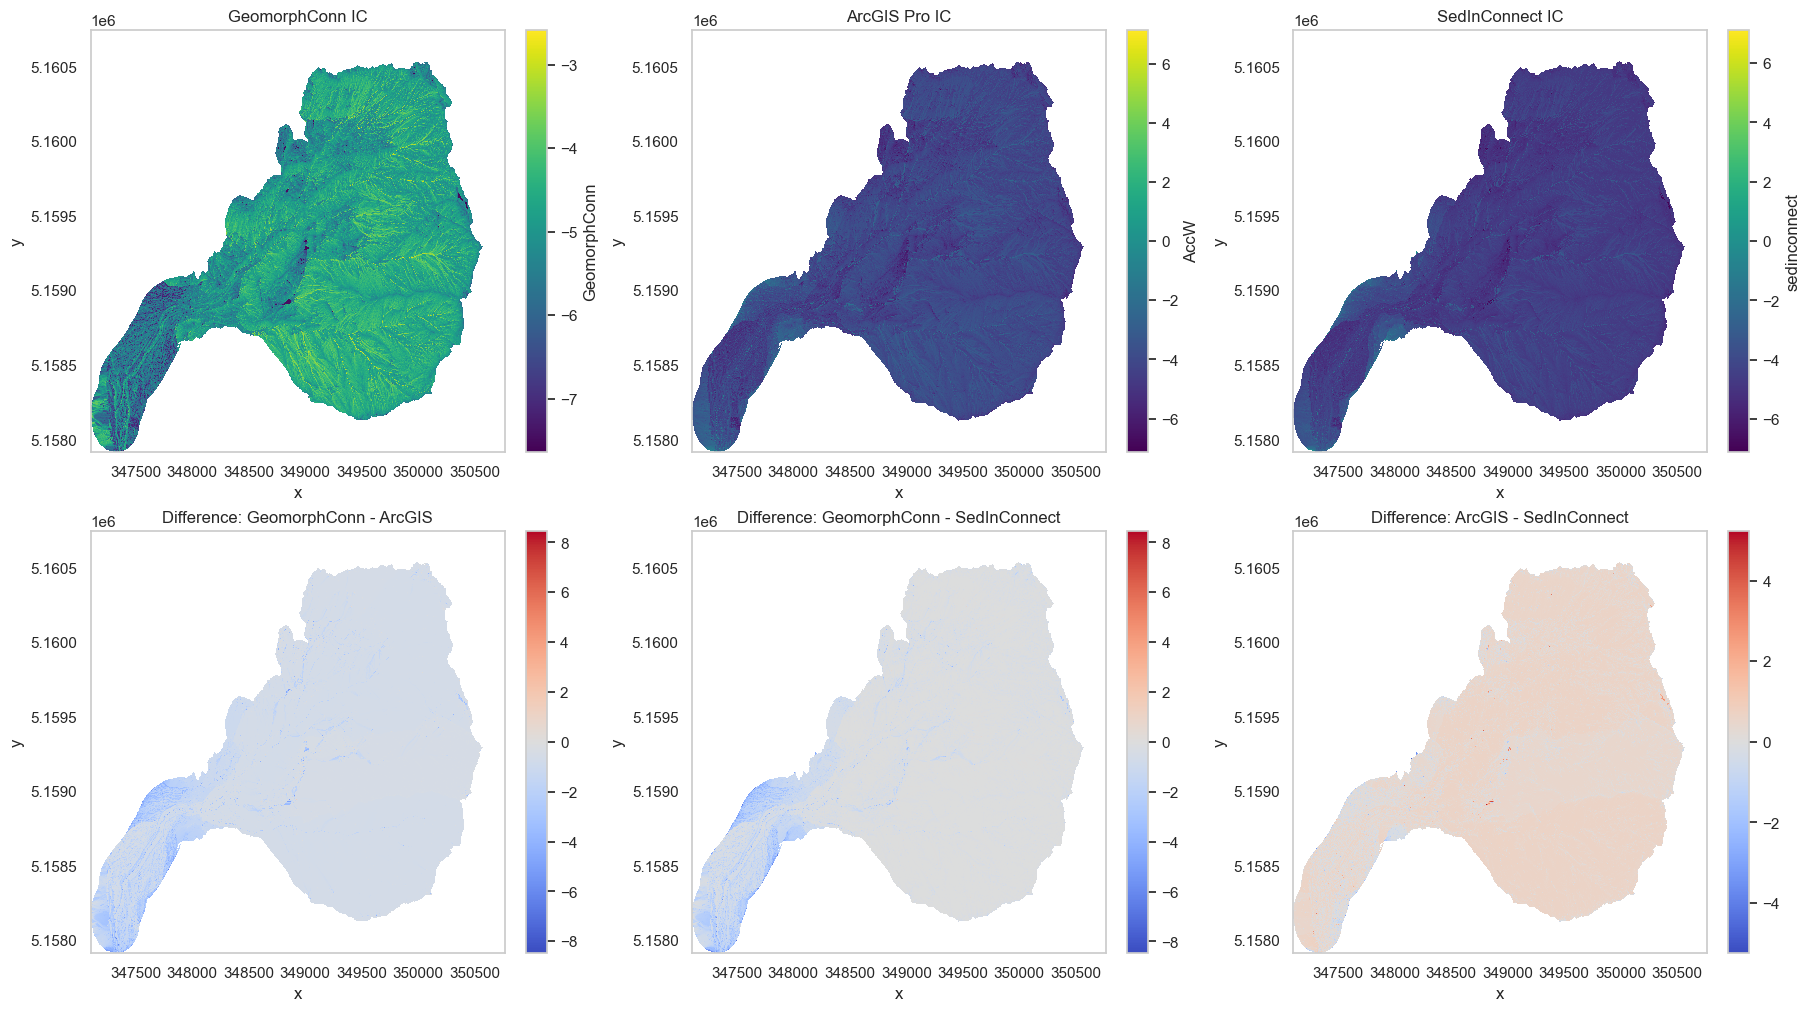

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Maps
stack_valid['GeomorphConn'].plot(ax=axes[0, 0], cmap='viridis')
axes[0, 0].set_title('GeomorphConn IC')

stack_valid['arcgis'].plot(ax=axes[0, 1], cmap='viridis')
axes[0, 1].set_title('ArcGIS Pro IC')

stack_valid['sedinconnect'].plot(ax=axes[0, 2], cmap='viridis')
axes[0, 2].set_title('SedInConnect IC')

# Difference maps
(stack_valid['GeomorphConn'] - stack_valid['arcgis']).plot(ax=axes[1, 0], cmap='coolwarm')
axes[1, 0].set_title('Difference: GeomorphConn - ArcGIS')

(stack_valid['GeomorphConn'] - stack_valid['sedinconnect']).plot(ax=axes[1, 1], cmap='coolwarm')
axes[1, 1].set_title('Difference: GeomorphConn - SedInConnect')

(stack_valid['arcgis'] - stack_valid['sedinconnect']).plot(ax=axes[1, 2], cmap='coolwarm')
axes[1, 2].set_title('Difference: ArcGIS - SedInConnect')

fig.savefig(OUT_DIR / 'maps_and_differences.png', dpi=200)
plt.show()

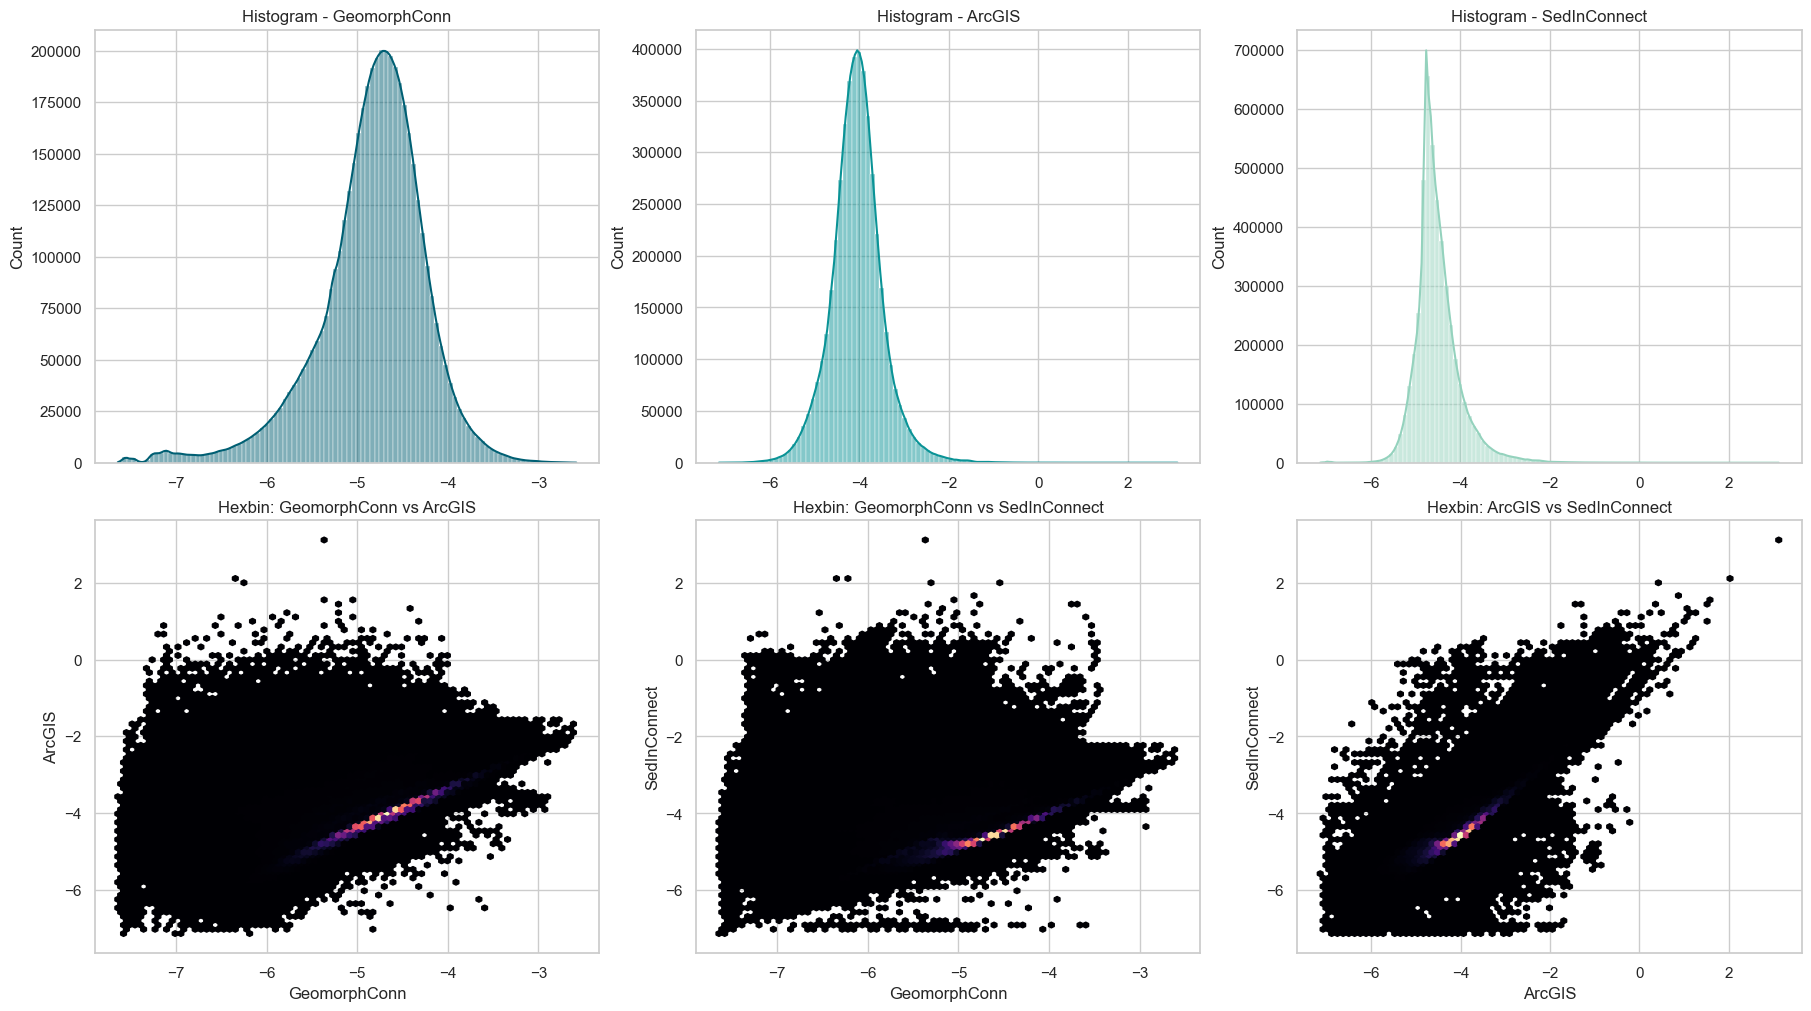

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Histograms
sns.histplot(s, bins=100, kde=True, ax=axes[0, 0], color='#005f73')
axes[0, 0].set_title('Histogram - GeomorphConn')
sns.histplot(a, bins=100, kde=True, ax=axes[0, 1], color='#0a9396')
axes[0, 1].set_title('Histogram - ArcGIS')
sns.histplot(c, bins=100, kde=True, ax=axes[0, 2], color='#94d2bd')
axes[0, 2].set_title('Histogram - SedInConnect')

# Scatter / hexbin
axes[1, 0].hexbin(s, a, gridsize=80, cmap='magma', mincnt=1)
axes[1, 0].set_xlabel('GeomorphConn')
axes[1, 0].set_ylabel('ArcGIS')
axes[1, 0].set_title('Hexbin: GeomorphConn vs ArcGIS')

axes[1, 1].hexbin(s, c, gridsize=80, cmap='magma', mincnt=1)
axes[1, 1].set_xlabel('GeomorphConn')
axes[1, 1].set_ylabel('SedInConnect')
axes[1, 1].set_title('Hexbin: GeomorphConn vs SedInConnect')

axes[1, 2].hexbin(a, c, gridsize=80, cmap='magma', mincnt=1)
axes[1, 2].set_xlabel('ArcGIS')
axes[1, 2].set_ylabel('SedInConnect')
axes[1, 2].set_title('Hexbin: ArcGIS vs SedInConnect')

fig.savefig(OUT_DIR / 'histograms_and_hexbin.png', dpi=200)
plt.show()

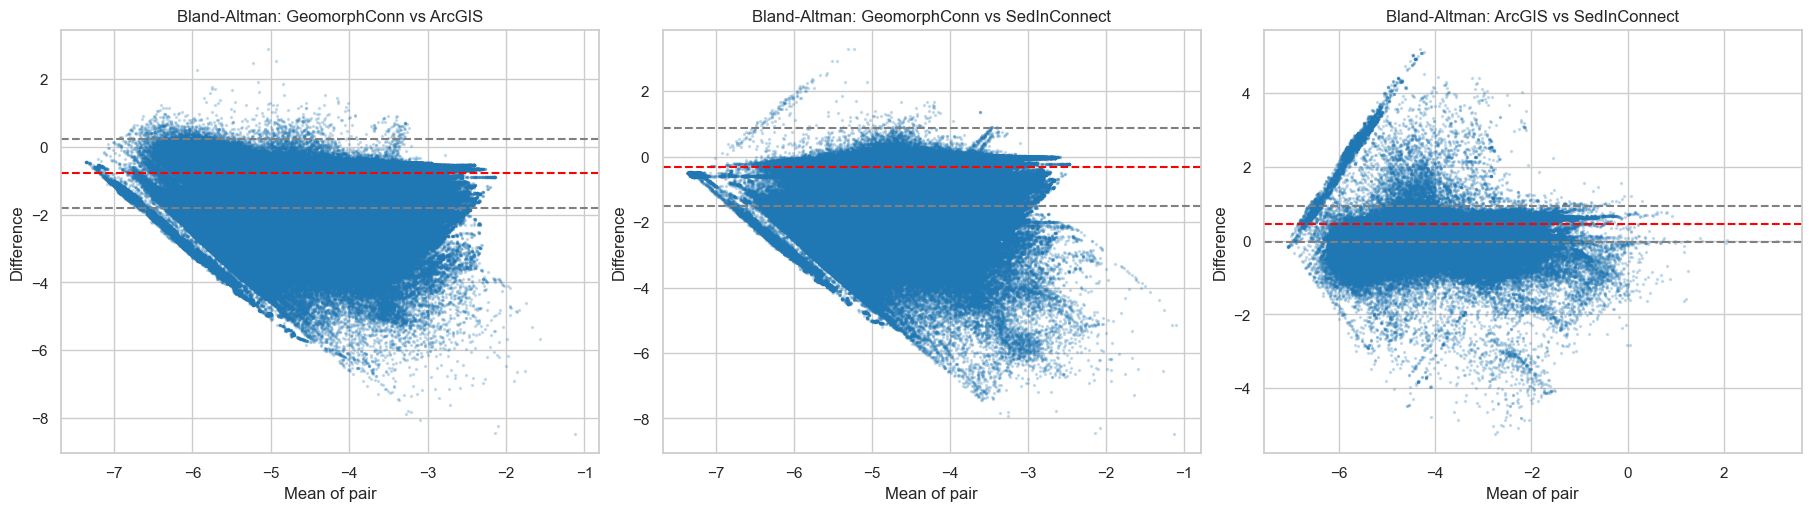

In [16]:
def bland_altman(ax, x, y, title):
    mean_xy = (x + y) / 2.0
    diff_xy = x - y
    md = np.mean(diff_xy)
    sd = np.std(diff_xy)

    ax.scatter(mean_xy, diff_xy, s=2, alpha=0.2)
    ax.axhline(md, color='red', linestyle='--', label='Mean diff')
    ax.axhline(md + 1.96 * sd, color='gray', linestyle='--', label='±1.96 SD')
    ax.axhline(md - 1.96 * sd, color='gray', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Mean of pair')
    ax.set_ylabel('Difference')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
bland_altman(axes[0], s, a, 'Bland-Altman: GeomorphConn vs ArcGIS')
bland_altman(axes[1], s, c, 'Bland-Altman: GeomorphConn vs SedInConnect')
bland_altman(axes[2], a, c, 'Bland-Altman: ArcGIS vs SedInConnect')

fig.savefig(OUT_DIR / 'bland_altman.png', dpi=200)
plt.show()

## Stratified Diagnostics by Terrain and Land Cover

This section breaks down software differences by terrain class (slope bins) and optionally land-cover classes.

Provide one or both optional rasters below:
- slope raster in degrees
- categorical land-cover raster

Both rasters are reprojected to the GeomorphConn IC grid before analysis.

In [ ]:
# ---- OPTIONAL STRATIFICATION INPUTS ----
SLOPE_RASTER = Path('data/slope_deg.tif')
LANDCOVER_RASTER = Path('data/landcover.tif')

slope_bins = [-np.inf, 2, 5, 10, 20, np.inf]
slope_labels = ['flat(<2)', 'gentle(2-5)', 'moderate(5-10)', 'steep(10-20)', 'very_steep(>20)']

slope_da = None
lc_da = None

if SLOPE_RASTER.exists():
    slope_da = open_singleband(SLOPE_RASTER).rio.reproject_match(ic_geomorphconn)
    print('Loaded slope raster:', SLOPE_RASTER)
else:
    print('Slope raster not found, skipping slope stratification:', SLOPE_RASTER)

if LANDCOVER_RASTER.exists():
    lc_da = open_singleband(LANDCOVER_RASTER).rio.reproject_match(ic_geomorphconn)
    print('Loaded land-cover raster:', LANDCOVER_RASTER)
else:
    print('Land-cover raster not found, skipping land-cover stratification:', LANDCOVER_RASTER)

In [ ]:
# Build analysis dataframe
df = pd.DataFrame({
    'GeomorphConn': stack_valid['GeomorphConn'].values.ravel(),
    'arcgis': stack_valid['arcgis'].values.ravel(),
    'sedinconnect': stack_valid['sedinconnect'].values.ravel(),
})

if slope_da is not None:
    df['slope_deg'] = slope_da.values.ravel()
    df['slope_class'] = pd.cut(df['slope_deg'], bins=slope_bins, labels=slope_labels)

if lc_da is not None:
    df['landcover'] = lc_da.values.ravel()

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['GeomorphConn', 'arcgis', 'sedinconnect'])

pair_names = [
    ('GeomorphConn', 'arcgis', 'geomorphconn_vs_arcgis'),
    ('GeomorphConn', 'sedinconnect', 'geomorphconn_vs_sedinconnect'),
    ('arcgis', 'sedinconnect', 'arcgis_vs_sedinconnect'),
]

def grouped_pair_metrics(g, x_col, y_col):
    x = g[x_col].to_numpy()
    y = g[y_col].to_numpy()
    diff = x - y
    out = {
        'n': len(g),
        'rmse': np.sqrt(np.mean(diff ** 2)),
        'mae': np.mean(np.abs(diff)),
        'bias': np.mean(diff),
        'pearson_r': stats.pearsonr(x, y).statistic if len(g) > 2 else np.nan,
    }
    return pd.Series(out)

strat_results = {}

if 'slope_class' in df.columns:
    slope_tables = []
    for x_col, y_col, pair_name in pair_names:
        t = df.dropna(subset=['slope_class']).groupby('slope_class', observed=False).apply(grouped_pair_metrics, x_col=x_col, y_col=y_col)
        t['pair'] = pair_name
        slope_tables.append(t.reset_index())
    strat_results['slope'] = pd.concat(slope_tables, ignore_index=True)

if 'landcover' in df.columns:
    lc_tables = []
    for x_col, y_col, pair_name in pair_names:
        t = df.dropna(subset=['landcover']).groupby('landcover', observed=False).apply(grouped_pair_metrics, x_col=x_col, y_col=y_col)
        t['pair'] = pair_name
        lc_tables.append(t.reset_index())
    strat_results['landcover'] = pd.concat(lc_tables, ignore_index=True)

if not strat_results:
    print('No stratification rasters available. Provide slope and/or land-cover rasters to run this section.')
else:
    for key, table in strat_results.items():
        out_csv = OUT_DIR / f'stratified_metrics_{key}.csv'
        table.to_csv(out_csv, index=False)
        print('Saved:', out_csv)
        display(table.head(20).round(5))

In [ ]:
# Plot stratified RMSE by slope and pair
if 'slope' in strat_results:
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    plot_df = strat_results['slope'].copy()
    sns.barplot(data=plot_df, x='slope_class', y='rmse', hue='pair', ax=ax)
    ax.set_title('RMSE by slope class and software pair')
    ax.set_xlabel('Slope class (deg)')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=25)
    fig.savefig(OUT_DIR / 'stratified_rmse_by_slope.png', dpi=200)
    plt.show()

# Plot stratified MAE by land-cover and pair
if 'landcover' in strat_results:
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    plot_df = strat_results['landcover'].copy()
    # Keep top classes by count for readability
    top_classes = plot_df.groupby('landcover')['n'].sum().sort_values(ascending=False).head(10).index
    plot_df = plot_df[plot_df['landcover'].isin(top_classes)]
    sns.barplot(data=plot_df, x='landcover', y='mae', hue='pair', ax=ax)
    ax.set_title('MAE by land-cover class and software pair (top 10 classes)')
    ax.set_xlabel('Land-cover class')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=30)
    fig.savefig(OUT_DIR / 'stratified_mae_by_landcover.png', dpi=200)
    plt.show()

## Interpretation Guide

- Low RMSE/MAE and near-zero bias indicate strong numerical agreement.
- High correlation with significant paired-test p-values can still indicate systematic bias (check Bland-Altman).
- Difference maps reveal where methods diverge spatially (e.g., near channels, flats, or edges).
- If ArcGIS and SedInConnect agree but `GeomorphConn` diverges in specific terrain classes, inspect preprocessing parity:
  - sink filling
  - flow routing algorithm
  - slope convention
  - weight raster scaling and nodata handling.


## Smeeton et al. (2014)-Inspired Analysis

This section adapts ideas from metric disconnectivity graphs to connectivity rasters:

1. Build hierarchical components by thresholding IC (analogous to energy levels).
2. Track parent-child component links across adjacent thresholds.
3. Plot a disconnectivity-like tree with:
   - y-axis: IC threshold (hierarchy level)
   - x-axis: selected metric (component mean IC)
4. Add metric axes inspired by Smeeton et al. (2014):
   - RMSd-like metric: component-level RMSE against a reference method
   - Contact-like metric: fraction of pixels with same sign class as reference
   - PCA metric: low-dimensional projection of multi-method IC vectors

In [17]:
from geomorphconn.analysis import (
    build_disconnectivity_hierarchy,
    compute_node_comparison_metrics,
)

# Build hierarchy using package API
hierarchy = build_disconnectivity_hierarchy(
    stack_valid["GeomorphConn"],
    quantiles=[0.50, 0.60, 0.70, 0.80, 0.90, 0.95],
    eight_connected=True,
)

nodes_df = pd.DataFrame(hierarchy["nodes"])
links_df = pd.DataFrame(hierarchy["links"])

nodes_out = OUT_DIR / "disconnectivity_nodes.csv"
links_out = OUT_DIR / "disconnectivity_links.csv"
nodes_df.to_csv(nodes_out, index=False)
links_df.to_csv(links_out, index=False)

print("Saved:", nodes_out)
print("Saved:", links_out)
print("Nodes:", len(nodes_df), "Links:", len(links_df))
display(nodes_df.head(20))
display(links_df.head(20))

Saved: outputs/ic_comparison/disconnectivity_nodes.csv
Saved: outputs/ic_comparison/disconnectivity_links.csv
Nodes: 51761 Links: 45335


,threshold,component_id,node_id,n_pixels,mean_ic,median_ic,std_ic,cx,cy,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax
0,-4.768658,1,T-4.768658_C1,1,-4.763753,-4.763753,0.000000,2868.000000,220.000000,2868,2868,220,220
1,-4.768658,2,T-4.768658_C2,59,-4.615851,-4.636993,0.101144,2870.084746,232.101695,2862,2879,224,238
2,-4.768658,3,T-4.768658_C3,1,-4.756736,-4.756736,0.000000,2883.000000,225.000000,2883,2883,225,225
3,-4.768658,4,T-4.768658_C4,2,-4.712171,-4.712171,0.006453,2880.500000,227.500000,2880,2881,227,228
4,-4.768658,5,T-4.768658_C5,1,-4.743682,-4.743682,0.000000,2878.000000,229.000000,2878,2878,229,229
5,-4.768658,6,T-4.768658_C6,8,-4.682749,-4.684151,0.027408,2647.500000,230.000000,2644,2651,230,230
6,-4.768658,7,T-4.768658_C7,4,-4.634022,-4.619048,0.060507,2860.000000,231.500000,2860,2860,230,233
7,-4.768658,8,T-4.768658_C8,2,-4.723946,-4.723946,0.020939,2875.500000,230.500000,2875,2876,230,231
8,-4.768658,9,T-4.768658_C9,4,-4.758806,-4.761139,0.009170,2881.500000,231.250000,2880,2883,230,232
9,-4.768658,10,T-4.768658_C10,2,-4.738876,-4.738876,0.017932,2638.500000,231.500000,2638,2639,231,232


,parent_threshold,parent_component_id,parent_node_id,child_threshold,child_component_id,child_node_id,overlap_pixels
0,-4.768658,2,T-4.768658_C2,-4.65224,1,T-4.652240_C1,1
1,-4.768658,2,T-4.768658_C2,-4.65224,2,T-4.652240_C2,32
2,-4.768658,2,T-4.768658_C2,-4.65224,3,T-4.652240_C3,2
3,-4.768658,6,T-4.768658_C6,-4.65224,4,T-4.652240_C4,1
4,-4.768658,7,T-4.768658_C7,-4.65224,5,T-4.652240_C5,2
5,-4.768658,12,T-4.768658_C12,-4.65224,6,T-4.652240_C6,1
6,-4.768658,16,T-4.768658_C16,-4.65224,7,T-4.652240_C7,1679959
7,-4.768658,20,T-4.768658_C20,-4.65224,8,T-4.652240_C8,6
8,-4.768658,12,T-4.768658_C12,-4.65224,9,T-4.652240_C9,1
9,-4.768658,23,T-4.768658_C23,-4.65224,10,T-4.652240_C10,3


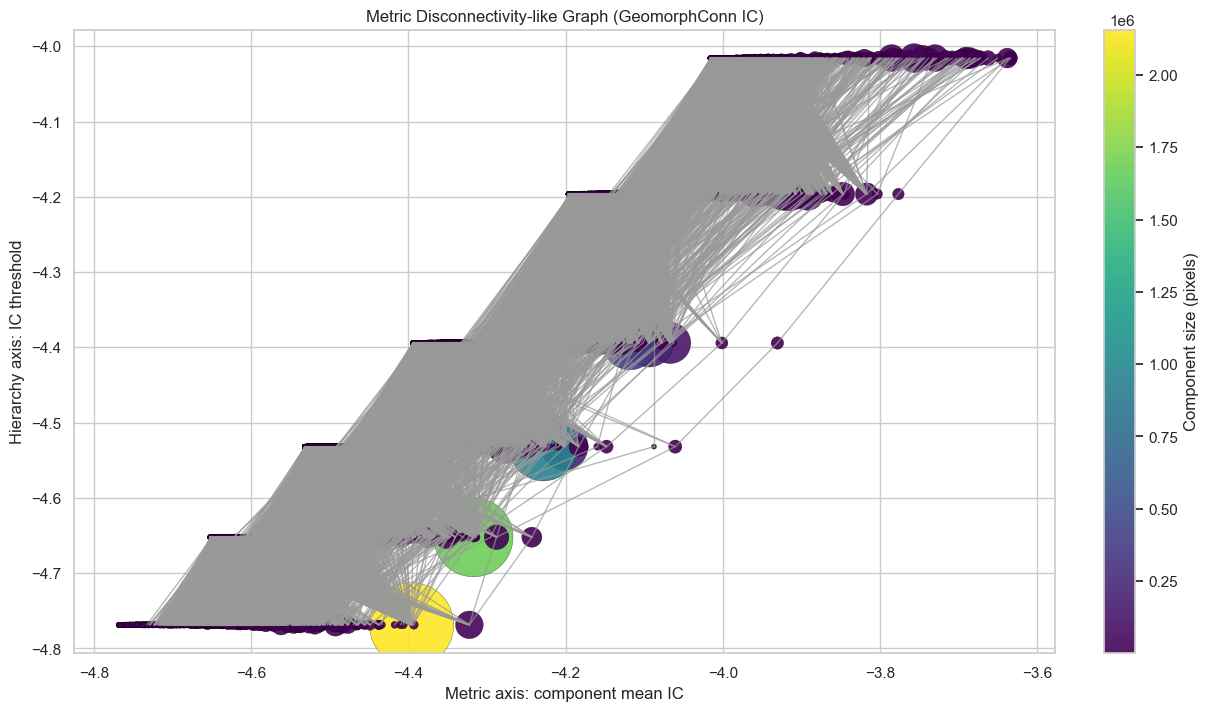

In [18]:
# Disconnectivity-like plot: threshold hierarchy + metric axis (mean IC)

node_pos = nodes_df.set_index("node_id")[["mean_ic", "threshold"]].to_dict("index")

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# Draw edges
for _, row in links_df.iterrows():
    p = row["parent_node_id"]
    cnode = row["child_node_id"]
    if p not in node_pos or cnode not in node_pos:
        continue
    x0, y0 = node_pos[p]["mean_ic"], node_pos[p]["threshold"]
    x1, y1 = node_pos[cnode]["mean_ic"], node_pos[cnode]["threshold"]
    ax.plot([x0, x1], [y0, y1], color="0.6", linewidth=1.0, alpha=0.7)

# Draw nodes (size by area)
sizes = 10 + 2.5 * np.sqrt(nodes_df["n_pixels"].to_numpy())
sc = ax.scatter(
    nodes_df["mean_ic"],
    nodes_df["threshold"],
    s=sizes,
    c=nodes_df["n_pixels"],
    cmap="viridis",
    alpha=0.9,
    edgecolor="k",
    linewidth=0.2,
)

ax.set_title("Metric Disconnectivity-like Graph (GeomorphConn IC)")
ax.set_xlabel("Metric axis: component mean IC")
ax.set_ylabel("Hierarchy axis: IC threshold")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Component size (pixels)")

fig.savefig(OUT_DIR / "metric_disconnectivity_like_graph.png", dpi=220)
plt.show()

In [19]:
# Additional Smeeton et al. (2014)-inspired metric axes using package API

node_metrics_rows = compute_node_comparison_metrics(
    hierarchy,
    reference_map=stack_valid["GeomorphConn"],
    comparison_maps={
        "arcgis": stack_valid["arcgis"],
        "sedinconnect": stack_valid["sedinconnect"],
    },
)

node_metrics_df = pd.DataFrame(node_metrics_rows)
node_metrics_out = OUT_DIR / "disconnectivity_node_metrics.csv"
node_metrics_df.to_csv(node_metrics_out, index=False)

print("Saved:", node_metrics_out)
display(node_metrics_df.head(20).round(5))

Saved: outputs/ic_comparison/disconnectivity_node_metrics.csv


,threshold,component_id,node_id,n_valid_pixels,rmse_vs_arcgis,bias_vs_arcgis,same_sign_vs_arcgis,rmse_vs_sedinconnect,bias_vs_sedinconnect,same_sign_vs_sedinconnect,pc1_var_explained
0,-4.76866,1,T-4.768658_C1,1,0.62623,-0.62623,1.0,0.01780,-0.01780,1.0,NaN
1,-4.76866,2,T-4.768658_C2,59,0.65015,-0.64203,1.0,0.10300,-0.04464,1.0,0.90813
2,-4.76866,3,T-4.768658_C3,1,0.62499,-0.62499,1.0,0.03206,-0.03206,1.0,NaN
3,-4.76866,4,T-4.768658_C4,2,0.62600,-0.62600,1.0,0.02436,-0.02434,1.0,1.00000
4,-4.76866,5,T-4.768658_C5,1,0.62857,-0.62857,1.0,0.02294,-0.02294,1.0,NaN
5,-4.76866,6,T-4.768658_C6,8,0.55829,-0.55829,1.0,0.01000,-0.00990,1.0,0.99936
6,-4.76866,7,T-4.768658_C7,4,0.61111,-0.61111,1.0,0.00686,-0.00647,1.0,0.99993
7,-4.76866,8,T-4.768658_C8,2,0.62749,-0.62749,1.0,0.02153,-0.02125,1.0,1.00000
8,-4.76866,9,T-4.768658_C9,4,0.61425,-0.61425,1.0,0.02498,-0.02485,1.0,0.98818
9,-4.76866,10,T-4.768658_C10,2,0.55876,-0.55876,1.0,0.01748,-0.01746,1.0,1.00000


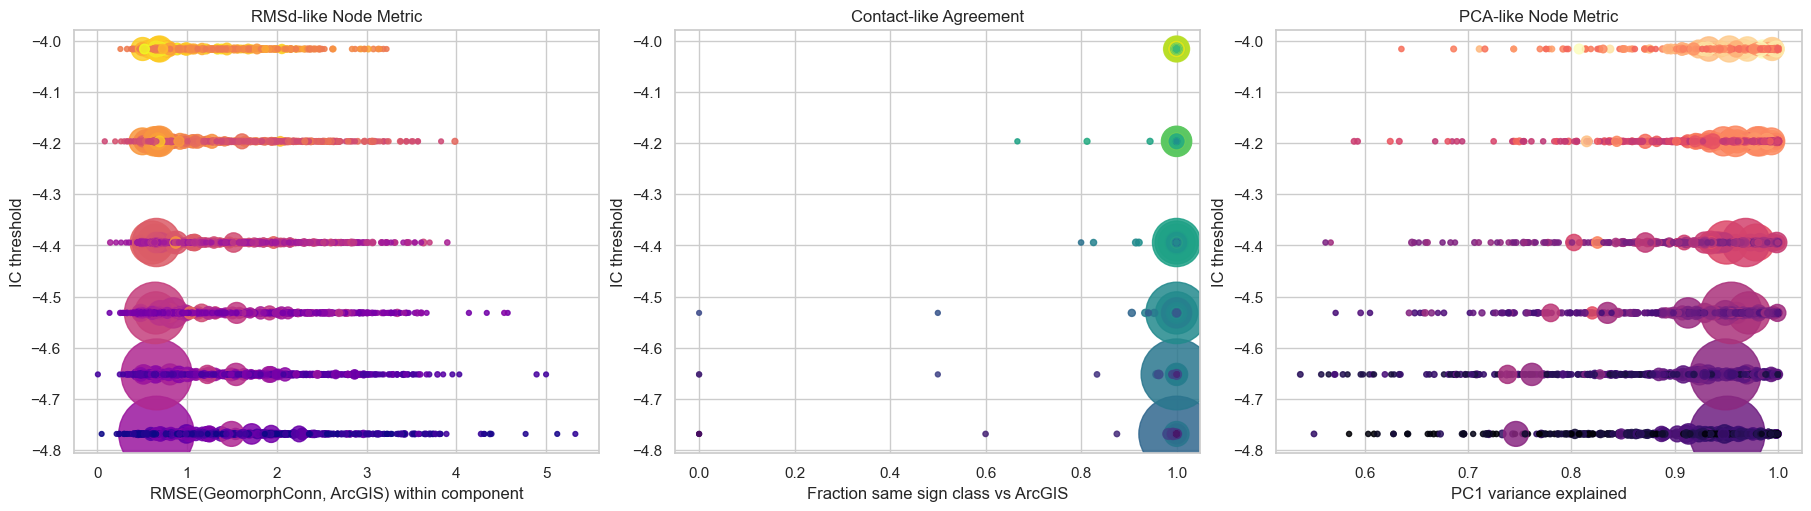

In [20]:
# Visualization of Smeeton et al. (2014)-inspired node metrics

merged_nodes = nodes_df.merge(node_metrics_df, on=["threshold", "component_id", "node_id"], how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 1) RMSd-like metric (GeomorphConn vs ArcGIS) vs hierarchy
axes[0].scatter(
    merged_nodes["rmse_vs_arcgis"],
    merged_nodes["threshold"],
    s=10 + 2.0 * np.sqrt(merged_nodes["n_pixels"]),
    c=merged_nodes["mean_ic"],
    cmap="plasma",
    alpha=0.85,
)
axes[0].set_title("RMSd-like Node Metric")
axes[0].set_xlabel("RMSE(GeomorphConn, ArcGIS) within component")
axes[0].set_ylabel("IC threshold")

# 2) Contact-like agreement vs hierarchy
axes[1].scatter(
    merged_nodes["same_sign_vs_arcgis"],
    merged_nodes["threshold"],
    s=10 + 2.0 * np.sqrt(merged_nodes["n_pixels"]),
    c=merged_nodes["mean_ic"],
    cmap="viridis",
    alpha=0.85,
)
axes[1].set_title("Contact-like Agreement")
axes[1].set_xlabel("Fraction same sign class vs ArcGIS")
axes[1].set_ylabel("IC threshold")

# 3) PCA metric plane (component means)
axes[2].scatter(
    merged_nodes["pc1_var_explained"],
    merged_nodes["threshold"],
    s=10 + 2.0 * np.sqrt(merged_nodes["n_pixels"]),
    c=merged_nodes["mean_ic"],
    cmap="magma",
    alpha=0.85,
)
axes[2].set_title("PCA-like Node Metric")
axes[2].set_xlabel("PC1 variance explained")
axes[2].set_ylabel("IC threshold")

fig.savefig(OUT_DIR / "smeeton2014_inspired_metrics.png", dpi=220)
plt.show()